In [1]:
# ===============================================
# 🧩 Colab_SyncMate — universal Colab↔GitHub helper
# ===============================================

from google.colab import userdata
from pathlib import Path
import os, subprocess, datetime

# --- CONFIG ---
GITHUB_USERNAME = "Retro099"                    # change if needed
GITHUB_REPO = "ML-Projects"                     # your repo name
PROJECT_FOLDER = "Japanese_Sentiment_Analysis/notebooks"  # default project folder

# --- TOKEN SETUP ---
ACCESS_TOKEN = userdata.get('GITHUB_TOKEN')
if not ACCESS_TOKEN:
    raise ValueError("⚠️ Missing GitHub token. Add one via Runtime → Run time secrets → name it GITHUB_TOKEN")

# --- PATHS ---
BASE_PATH = Path("/content")
REPO_PATH = BASE_PATH / GITHUB_REPO
REPO_URL = f"https://{ACCESS_TOKEN}@github.com/{GITHUB_USERNAME}/{GITHUB_REPO}.git"

# --- CLONE OR UPDATE REPO ---
if REPO_PATH.exists():
    os.chdir(REPO_PATH)
    subprocess.run(["git", "pull"], check=False)
else:
    os.chdir(BASE_PATH)
    subprocess.run(["git", "clone", REPO_URL], check=False)
    os.chdir(REPO_PATH)

# --- MOVE TO PROJECT FOLDER ---
proj_path = REPO_PATH / PROJECT_FOLDER
proj_path.mkdir(parents=True, exist_ok=True)
os.chdir(proj_path)

print(f"✅ Repo ready at: {REPO_PATH}")
print(f"✅ Project folder: {proj_path}")

# --- UTILITIES ---
def save_notebook(dst=None):
    """Force-save current notebook state to disk."""
    from google.colab import _message
    if not dst:
        dst = os.getcwd()
    _message.blocking_request('save_notebook', {'path': dst})
    print(f"💾 Notebook saved to {dst}")

def quick_commit_push(msg="Autosave commit"):
    """Commit and push changes quickly to GitHub."""
    os.chdir(REPO_PATH)
    subprocess.run(["git", "add", "-A"], check=False)
    subprocess.run(["git", "commit", "-m", msg], check=False)
    subprocess.run(["git", "push", "origin", "main"], check=False)
    print("✅ Repo synced with GitHub")

def safe_backup(tag=None):
    """Create a timestamped local backup inside /content."""
    tag = tag or datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    backup_dir = BASE_PATH / f"Backup_{GITHUB_REPO}_{tag}"
    subprocess.run(["cp", "-r", str(REPO_PATH), str(backup_dir)])
    print(f"🧾 Local backup created at: {backup_dir}")

def unified_shutdown():
    """Cleanly commit, push, and unmount before ending session."""
    try:
        quick_commit_push("Session wrap-up via Colab_SyncMate")
    except Exception as e:
        print("⚠️ Commit/push skipped:", e)
    try:
        from google.colab import drive
        drive.flush_and_unmount()
    except:
        pass
    print("💤 Session safely closed. Now disconnect runtime via Runtime → Disconnect and delete runtime.")

print("\n🧩 Colab_SyncMate initialized.\nAvailable commands:")
print("  • save_notebook()        – flush in-memory notebook")
print("  • quick_commit_push(msg) – commit and push instantly")
print("  • safe_backup(tag)       – create timestamped backup")
print("  • unified_shutdown()     – final sync + clean close")
print("\n⚙️  Tip: Run this notebook once per Colab session before opening your project.")


✅ Repo ready at: /content/ML-Projects
✅ Project folder: /content/ML-Projects/Japanese_Sentiment_Analysis/notebooks

🧩 Colab_SyncMate initialized.
Available commands:
  • save_notebook()        – flush in-memory notebook
  • quick_commit_push(msg) – commit and push instantly
  • safe_backup(tag)       – create timestamped backup
  • unified_shutdown()     – final sync + clean close

⚙️  Tip: Run this notebook once per Colab session before opening your project.


In [2]:
# ── ULTIMATE ONE-SHOT FIX (explicit fugashi + unidic_lite) ──
!pip uninstall -y torchvision torchaudio --quiet

!pip install --quiet fugashi unidic-lite
!pip install --quiet transformers datasets evaluate accelerate gradio japanize-matplotlib pandas==2.2.2 scikit-learn

import pandas as pd
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import japanize_matplotlib
import matplotlib.pyplot as plt

print("✅ ALL LIBRARIES LOADED SUCCESSFULLY!")
print("Torch version:", torch.__version__)
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")

✅ ALL LIBRARIES LOADED SUCCESSFULLY!
Torch version: 2.5.1+cu124
Device: CUDA


In [3]:
classifier = pipeline("sentiment-analysis",
                      model="jarvisx17/japanese-sentiment-analysis",
                      device=0 if torch.cuda.is_available() else -1)

test_sentences = [
    "この商品は最高です！とても満足しています。",
    "最悪の買い物だった。返品したい。",
    "普通の商品ですね。期待通りでした。"
]

results = classifier(test_sentences)
for sent, res in zip(test_sentences, results):
    print(f"📝 {sent}\n→ {res['label']} (score: {res['score']:.3f})\n")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cuda:0


📝 この商品は最高です！とても満足しています。
→ positive (score: 1.000)

📝 最悪の買い物だった。返品したい。
→ negative (score: 1.000)

📝 普通の商品ですね。期待通りでした。
→ positive (score: 1.000)



In [5]:
from datasets import load_dataset

# FINAL FIX: ver2 + safe handling for dict 'avg_readers'
dataset = load_dataset("shunk031/wrime", "ver2", trust_remote_code=True)

print("✅ Dataset columns:", dataset['train'].column_names)
print("Sample avg_readers structure:", dataset['train'][0]['avg_readers'])  # ← debug

small = dataset['train'].shuffle(seed=42).select(range(10000))

def map_label(example):
    avg = example['avg_readers']
    # Handle dict case (common in ver2)
    if isinstance(avg, dict):
        intensity = sum(avg.values()) / len(avg) if avg else 0.0
    else:
        intensity = float(avg) if avg is not None else 0.0

    example['label'] = 2 if intensity > 0.25 else 0 if intensity < -0.25 else 1
    return example

small = small.map(map_label)

tokenizer = AutoTokenizer.from_pretrained("cl-tohoku/bert-base-japanese-v2")

def tokenize(examples):
    return tokenizer(examples["sentence"], truncation=True, padding=True, max_length=128)

tokenized = small.map(tokenize, batched=True)
tokenized = tokenized.train_test_split(test_size=0.2, seed=42)

print("✅ Tokenized | Train:", len(tokenized['train']), "Test:", len(tokenized['test']))

✅ Dataset columns: ['sentence', 'user_id', 'datetime', 'writer', 'reader1', 'reader2', 'reader3', 'avg_readers']
Sample avg_readers structure: {'joy': 0, 'sadness': 2, 'anticipation': 0, 'surprise': 0, 'anger': 0, 'fear': 0, 'disgust': 0, 'trust': 0, 'sentiment': -1}


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/517 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Parameter 'function'=<function tokenize at 0x7d2d892f53a0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

✅ Tokenized | Train: 8000 Test: 2000


In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    "cl-tohoku/bert-base-japanese-v2", num_labels=3
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

print("✅ Model + Training args ready!")

pytorch_model.bin:   0%|          | 0.00/447M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model + Training args ready!


/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [7]:
from evaluate import load
import numpy as np

f1_metric = load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return f1_metric.compute(predictions=predictions, references=labels, average="weighted")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['test'],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

print("🚀 Starting training...")
trainer.train()
print("✅ Training completed!")

/tmp/ipykernel_13456/1742755523.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


🚀 Starting training...


Epoch,Training Loss,Validation Loss,F1
1,0.577300,0.512433,0.745109
2,0.386200,0.564205,0.750705


✅ Training completed!


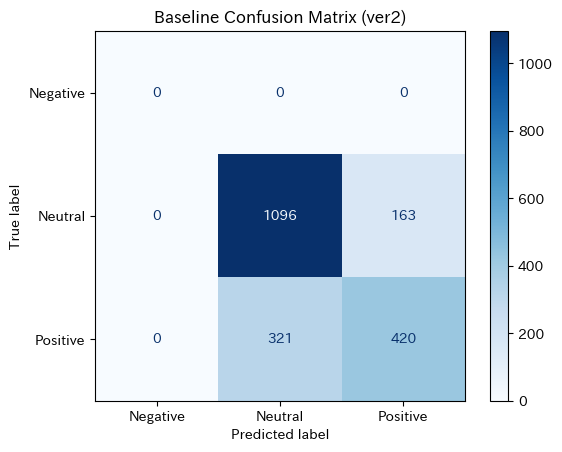

✅ Weighted F1 Score: 0.7507
Class distribution in test set: 1    1259
2     741
Name: count, dtype: int64


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import os
from pathlib import Path

# Create assets folder
assets_path = Path("/content/ML-Projects/Japanese_Sentiment_Analysis/assets")
assets_path.mkdir(parents=True, exist_ok=True)

predictions = trainer.predict(tokenized['test'])
preds = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(tokenized['test']['label'], preds, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap="Blues")
plt.title("Baseline Confusion Matrix (ver2)")
plt.savefig(assets_path / "day2_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

f1_metric = load("f1")
f1_score = f1_metric.compute(predictions=preds, references=tokenized['test']['label'], average="weighted")
print("✅ Weighted F1 Score:", round(f1_score['f1'], 4))
print("Class distribution in test set:", pd.Series(tokenized['test']['label']).value_counts().sort_index())

In [13]:
%%writefile /content/ML-Projects/Japanese_Sentiment_Analysis/app.py
import streamlit as st
from transformers import pipeline

st.title("🇯🇵 Japanese Sentiment Analysis")
st.write("Day 2 baseline model (Positive / Neutral / Negative)")

classifier = pipeline("sentiment-analysis",
                      model="cl-tohoku/bert-base-japanese-v2",
                      device=0 if st.runtime.exists("cuda") else -1)

text = st.text_area("レビューを入力してください", "この商品は最高です！とても満足しています。")
if st.button("分析する"):
    result = classifier(text)[0]
    label_map = {"positive": "Positive 😊", "negative": "Negative 😞", "neutral": "Neutral 😐"}
    st.success(f"予測: {label_map.get(result['label'].lower(), result['label'])} (score: {result['score']:.3f})")

Writing /content/ML-Projects/Japanese_Sentiment_Analysis/app.py
